# Hearthstone Battlegrounds â€” Dataset Explorer

Loads all parsed game sessions and lets you explore what your final boards look like, hero performance, health trends, and more.

In [1]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from hearthstone.cardxml import load_dbf

# â”€â”€ card name lookup â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
db, _ = load_dbf()
_CARD_DB = {c.id: c for c in db.values()}

def card_name(card_id: str) -> str:
    c = _CARD_DB.get(card_id)
    return c.name if c else card_id

# â”€â”€ load all sessions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
DATA_DIR = Path("data")

games = []
for f in sorted(DATA_DIR.glob("Hearthstone_*.json")):
    games.extend(json.loads(f.read_text(encoding="utf-8")))

print(f"Loaded {len(games)} games across {len(list(DATA_DIR.glob('Hearthstone_*.json')))} sessions")

Loaded 5 games across 5 sessions


## Dataset Overview

In [2]:
rows = []
for g in games:
    hero   = g.get("hero") or {}
    rounds = g.get("rounds", [])
    last   = rounds[-1] if rounds else {}
    last_shopping = last.get("shopping") or {}
    last_combat   = last.get("combat")   or {}

    rows.append({
        "session":      g["session"],
        "game_index":   g["game_index"],
        "hero_card_id": hero.get("card_id", ""),
        "hero_name":    card_name(hero.get("card_id", "")),
        "placement":    g.get("placement"),
        "won":          g.get("placement") == 1,
        "num_rounds":   len(rounds),
        "anomaly":      g.get("anomaly"),
        "final_health": last_combat.get("hero_health_after", 0),
        "final_armor":  last_combat.get("hero_armor_after",  0),
        "final_tier":   last_shopping.get("tavern_tier", 0),
        "final_board":  last_combat.get("player_board", []),
    })

df = pd.DataFrame(rows)

wins   = df["won"].sum()
losses = len(df) - wins
print(f"Total games : {len(df)}")
print(f"Wins        : {wins}  ({wins/len(df)*100:.0f}%)")
print(f"Losses/other: {losses}")
print(f"Avg rounds  : {df['num_rounds'].mean():.1f}")
print()
df[["session","hero_name","won","num_rounds","final_tier"]]

Total games : 5
Wins        : 5  (100%)
Losses/other: 0
Avg rounds  : 15.4



,session,hero_name,won,num_rounds,final_tier
0,Hearthstone_2026_03_06_17_51_02,The Rat King,True,14,6
1,Hearthstone_2026_03_08_21_10_37,Ambassador Faelin,True,14,6
2,Hearthstone_2026_03_12_16_20_10,Fungalmancer Flurgl,True,18,6
3,Hearthstone_2026_03_13_17_24_20,Varden Dawngrasp,True,17,6
4,Hearthstone_2026_03_13_22_44_35,Arch-Villain Rafaam,True,14,6


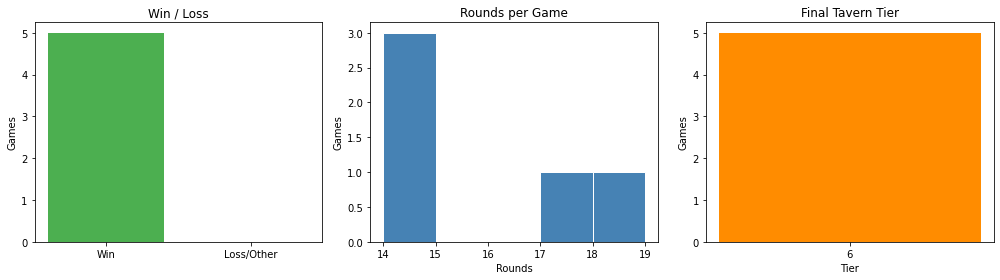

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(["Win", "Loss/Other"], [wins, losses], color=["#4CAF50", "#F44336"])
axes[0].set_title("Win / Loss")
axes[0].set_ylabel("Games")

axes[1].hist(df["num_rounds"], bins=range(df["num_rounds"].min(), df["num_rounds"].max()+2), color="steelblue", edgecolor="white")
axes[1].set_title("Rounds per Game")
axes[1].set_xlabel("Rounds")
axes[1].set_ylabel("Games")

tier_counts = df["final_tier"].value_counts().sort_index()
axes[2].bar(tier_counts.index.astype(str), tier_counts.values, color="darkorange")
axes[2].set_title("Final Tavern Tier")
axes[2].set_xlabel("Tier")
axes[2].set_ylabel("Games")

plt.tight_layout()
plt.show()

## Final Board Lineup

The board going into the **last combat** of each game, split by outcome.

In [4]:
def board_minion_counts(game_rows, top_n=15):
    counter = Counter()
    total_games = 0
    for _, row in game_rows.iterrows():
        board = row["final_board"]
        if not board:
            continue
        total_games += 1
        for minion in board:
            name = card_name(minion["card_id"]) if minion["card_id"] else "Unknown"
            if minion.get("golden"):
                name = f"{name} â˜…"
            counter[name] += 1
    return counter.most_common(top_n), total_games

win_rows  = df[df["won"] == True]
loss_rows = df[df["won"] == False]

win_counts,  win_n  = board_minion_counts(win_rows)
loss_counts, loss_n = board_minion_counts(loss_rows)

print(f"Final boards with data â€” Wins: {win_n}, Losses: {loss_n}")

Final boards with data â€” Wins: 5, Losses: 0


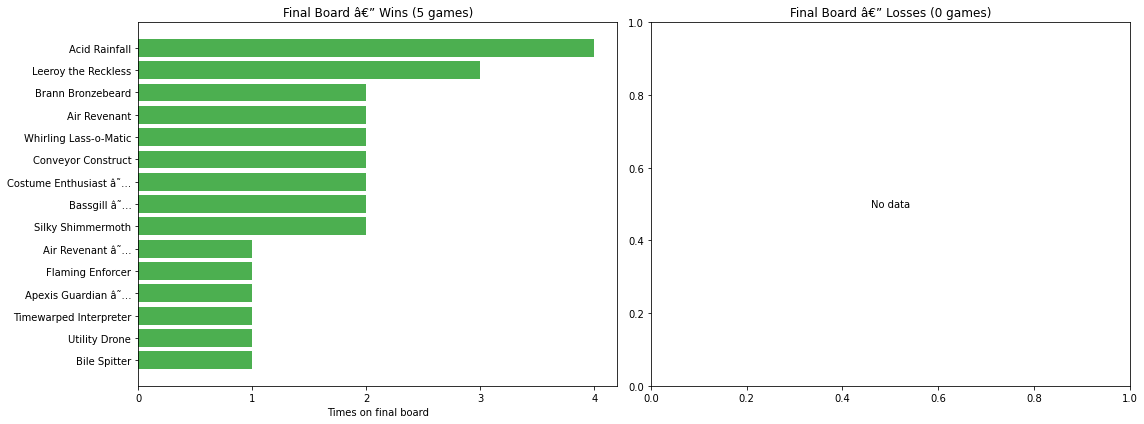

In [5]:
def plot_board_counts(counts, title, ax, color):
    if not counts:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    names, vals = zip(*counts)
    ax.barh(list(reversed(names)), list(reversed(vals)), color=color)
    ax.set_xlabel("Times on final board")
    ax.set_title(title)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_board_counts(win_counts,  f"Final Board â€” Wins ({win_n} games)",  axes[0], "#4CAF50")
plot_board_counts(loss_counts, f"Final Board â€” Losses ({loss_n} games)", axes[1], "#F44336")
plt.tight_layout()
plt.show()

### Final Board Stats (Wins)

In [6]:
def board_stats_df(game_rows):
    records = []
    for _, row in game_rows.iterrows():
        for m in row["final_board"]:
            records.append({
                "name":         card_name(m["card_id"]) if m["card_id"] else "Unknown",
                "golden":       m.get("golden", False),
                "attack":       m.get("attack", 0),
                "health":       m.get("health", 0),
                "tier":         m.get("tier", 0),
                "divine_shield":m.get("divine_shield", False),
                "taunt":        m.get("taunt", False),
                "reborn":       m.get("reborn", False),
                "poisonous":    m.get("poisonous", False),
                "windfury":     m.get("windfury", False),
            })
    return pd.DataFrame(records)

win_board_df = board_stats_df(win_rows)

if not win_board_df.empty:
    summary = (
        win_board_df.groupby("name")
        .agg(
            count=("name", "count"),
            avg_atk=("attack", "mean"),
            avg_hp=("health", "mean"),
            avg_tier=("tier", "mean"),
            golden=("golden", "sum"),
            div_shield=("divine_shield", "sum"),
            taunt=("taunt", "sum"),
            reborn=("reborn", "sum"),
        )
        .sort_values("count", ascending=False)
        .reset_index()
    )
    summary[["avg_atk","avg_hp","avg_tier"]] = summary[["avg_atk","avg_hp","avg_tier"]].round(1)
    display(summary)
else:
    print("No winning game boards found yet.")

,name,count,avg_atk,avg_hp,avg_tier,golden,div_shield,taunt,reborn
0,Acid Rainfall,4,1546.5,1517.2,6,0,0,0,0
1,Brann Bronzebeard,3,11.7,15.3,5,1,0,1,0
2,Air Revenant,3,444.0,441.0,5,1,0,1,0
3,Costume Enthusiast,3,77.0,106.0,5,2,3,0,0
4,Leeroy the Reckless,3,31.7,35.3,5,0,0,2,0
5,Conveyor Construct,2,128.0,118.0,4,0,0,2,0
6,Bassgill,2,171.0,184.5,3,2,0,0,0
7,Silky Shimmermoth,2,20.5,40.5,6,0,0,0,0
8,Whirling Lass-o-Matic,2,175.5,273.0,6,0,2,0,0
9,Bile Spitter,1,57.0,65.0,5,0,0,0,0


## Hero Performance

In [7]:
hero_stats = (
    df.groupby("hero_name")
    .agg(
        games=("won", "count"),
        wins=("won", "sum"),
        avg_rounds=("num_rounds", "mean"),
        avg_tier=("final_tier", "mean"),
    )
    .assign(win_rate=lambda x: (x["wins"] / x["games"] * 100).round(0))
    .sort_values("games", ascending=False)
    .reset_index()
)
hero_stats[["avg_rounds","avg_tier"]] = hero_stats[["avg_rounds","avg_tier"]].round(1)
display(hero_stats)

,hero_name,games,wins,avg_rounds,avg_tier,win_rate
0,Ambassador Faelin,1,1,14,6,100.0
1,Arch-Villain Rafaam,1,1,14,6,100.0
2,Fungalmancer Flurgl,1,1,18,6,100.0
3,The Rat King,1,1,14,6,100.0
4,Varden Dawngrasp,1,1,17,6,100.0


## Health Progression Over Rounds

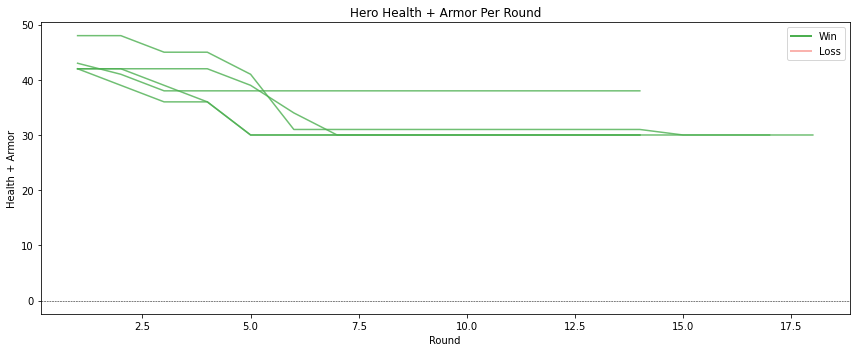

In [8]:
def health_series(game):
    pts = []
    for r in game["rounds"]:
        combat = r.get("combat") or {}
        hp     = combat.get("hero_health_after", None)
        armor  = combat.get("hero_armor_after",  0)
        if hp is not None:
            pts.append((r["round"], hp + armor))
    return pts

fig, ax = plt.subplots(figsize=(12, 5))

for g in games:
    pts = health_series(g)
    if not pts:
        continue
    rounds, hps = zip(*pts)
    won   = g.get("placement") == 1
    color = "#4CAF50" if won else "#F44336"
    alpha = 0.8 if won else 0.4
    ax.plot(rounds, hps, color=color, alpha=alpha, linewidth=1.5)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color="#4CAF50", lw=2, label="Win"),
    Line2D([0],[0], color="#F44336", lw=2, alpha=0.4, label="Loss"),
])
ax.set_xlabel("Round")
ax.set_ylabel("Health + Armor")
ax.set_title("Hero Health + Armor Per Round")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

## Keyword Frequency on Final Boards (Wins vs Losses)

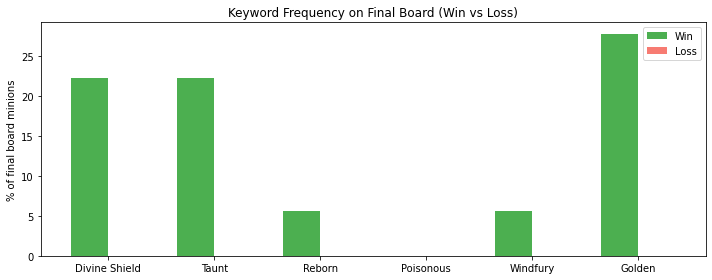

In [9]:
keywords = ["divine_shield", "taunt", "reborn", "poisonous", "windfury", "golden"]

def keyword_rates(game_rows):
    total_minions = 0
    kw_counts = Counter()
    for _, row in game_rows.iterrows():
        for m in row["final_board"]:
            total_minions += 1
            for kw in keywords:
                if m.get(kw):
                    kw_counts[kw] += 1
    if total_minions == 0:
        return {}
    return {kw: kw_counts[kw] / total_minions * 100 for kw in keywords}

win_kw  = keyword_rates(win_rows)
loss_kw = keyword_rates(loss_rows)

if win_kw or loss_kw:
    x      = range(len(keywords))
    w_vals = [win_kw.get(k, 0)  for k in keywords]
    l_vals = [loss_kw.get(k, 0) for k in keywords]

    fig, ax = plt.subplots(figsize=(10, 4))
    width = 0.35
    ax.bar([i - width/2 for i in x], w_vals, width, label="Win",  color="#4CAF50")
    ax.bar([i + width/2 for i in x], l_vals, width, label="Loss", color="#F44336", alpha=0.7)
    ax.set_xticks(list(x))
    ax.set_xticklabels([k.replace("_", " ").title() for k in keywords])
    ax.set_ylabel("% of final board minions")
    ax.set_title("Keyword Frequency on Final Board (Win vs Loss)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough board data yet.")

---
## Behavioral Cloning

**Behavioral Cloning (BC)** is the simplest form of imitation learning: treat your own gameplay as a dataset of expert demonstrations and train a supervised classifier to predict which action to take given the current game state.

### What the model learns
For every shopping phase in every recorded game, we reconstruct the game state *before each action* and record what action was taken.  
The model then learns a mapping: **state â†’ action**.

### State encoding (181 features)
| Component | Features |
|-----------|----------|
| Context (round, tier, hp, armor, **gold**) | 5 |
| Shop â€” 7 minion slots Ã— 11 features | 77 |
| Board â€” 7 minion slots Ã— 11 features | 77 |
| Hand â€” 2 minion slots Ã— 11 features | 22 |

Each minion is encoded as: `[atk, hp, divine_shield, taunt, reborn, poisonous, windfury, golden, tier, zone_pos, is_present]`  
Gold is the gold **remaining before the action is taken**, read directly from the logged `gold_remaining` field.

### Action space (19 classes)
`buy_0..6` Â· `sell_0..6` Â· `place` Â· `reroll` Â· `freeze` Â· `level_up` Â· `end_turn`

### Limitations with small data
With < 100 games the model will overfit. Treat this as a framework ready to scale â€” the architecture, data pipeline, and training loop are all correct. With 500+ games this becomes genuinely useful.

In [10]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# â”€â”€ Action index constants â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# 0-6   buy shop slot 0..6
# 7-13  sell board slot 0..6
# 14    place (from hand)
# 15    reroll
# 16    freeze
# 17    level_up
# 18    end_turn
N_ACTIONS    = 19
ACTION_NAMES = ([f"buy_{i}" for i in range(7)] +
                [f"sell_{i}" for i in range(7)] +
                ["place", "reroll", "freeze", "level_up", "end_turn"])

MAX_SHOP      = 7
MAX_BOARD     = 7
MAX_HAND      = 2
MINION_FEATS  = 11   # atk hp divine_shield taunt reborn poisonous windfury golden tier zone_pos is_present
CONTEXT_FEATS = 5    # round tier health armor gold
STATE_DIM     = CONTEXT_FEATS + (MAX_SHOP + MAX_BOARD + MAX_HAND) * MINION_FEATS  # = 181

print(f"State dimension : {STATE_DIM}")
print(f"Action classes  : {N_ACTIONS}")
print(f"Action names    : {ACTION_NAMES}")

State dimension : 181
Action classes  : 19
Action names    : ['buy_0', 'buy_1', 'buy_2', 'buy_3', 'buy_4', 'buy_5', 'buy_6', 'sell_0', 'sell_1', 'sell_2', 'sell_3', 'sell_4', 'sell_5', 'sell_6', 'place', 'reroll', 'freeze', 'level_up', 'end_turn']


### Feature Encoding

In [11]:
def encode_minion(m: dict) -> list:
    """Encode one minion as an 11-dim float vector."""
    return [
        m.get("attack", 0)       / 10.0,
        m.get("health", 0)       / 10.0,
        float(m.get("divine_shield", False)),
        float(m.get("taunt",        False)),
        float(m.get("reborn",       False)),
        float(m.get("poisonous",    False)),
        float(m.get("windfury",     False)),
        float(m.get("golden",       False)),
        m.get("tier", 1)         / 6.0,
        m.get("zone_pos", 0)     / 7.0,
        1.0,   # is_present
    ]

_EMPTY_MINION = [0.0] * MINION_FEATS  # padding for empty slots

def encode_slot_list(minions: list, max_slots: int) -> list:
    """Encode a variable-length minion list into a fixed-size flat vector."""
    feats = []
    for i in range(max_slots):
        feats.extend(encode_minion(minions[i]) if i < len(minions) else _EMPTY_MINION)
    return feats

def encode_state(round_num: int, tier: int, health: int, armor: int,
                 shop: list, board: list, hand: list, gold: int = 0) -> list:
    context = [round_num / 20.0, tier / 6.0, health / 40.0, armor / 40.0, gold / 10.0]
    return (context
            + encode_slot_list(shop,  MAX_SHOP)
            + encode_slot_list(board, MAX_BOARD)
            + encode_slot_list(hand,  MAX_HAND))

def find_by_card_id(lst: list, card_id: str) -> int:
    """Return index of first minion with matching card_id, or -1."""
    for i, m in enumerate(lst):
        if m.get("card_id") == card_id:
            return i
    return -1

print(f"encode_state output length: {len(encode_state(1,1,30,0,[],[],[]))}  (expected {STATE_DIM})")

encode_state output length: 181  (expected 181)


### Action Masking

Not every action is legal in every state. A mask vector marks which of the 19 actions are currently valid, derived entirely from the encoded state vector (no extra data needed).

| Rule | Affected actions |
|------|-----------------|
| Shop slot must exist | `buy_i` only if shop slot `i` is occupied |
| Gold â‰¥ 3 to buy | all `buy_i` |
| Hand must not be full (â‰¥ 10) | all `buy_i` |
| Board slot must exist | `sell_i` only if board slot `i` is occupied |
| Hand non-empty **and** board < 7 | `place` |
| Gold â‰¥ 1 | `reroll` |
| Gold â‰¥ level-up cost (approx.) | `level_up` |
| `freeze` and `end_turn` | always valid |

> **Spells** â€” BG spell cards (e.g. tavern spells) appear in the shop and are played directly. Supporting them requires the parser to also track `CARDTYPE=SPELL` entities in `ZONE=SETASIDE` and a new `play_spell_0..6` action group. The masking rule would be: play_spell_i valid if shop spell slot i exists and gold â‰¥ spell cost.

In [12]:
# â”€â”€ Zone offsets into the flat state vector â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Context: indices 0-4  (round, tier, health, armor, gold)
# Shop:    indices 5 .. 5+MAX_SHOP*MINION_FEATS-1
# Board:   next MAX_BOARD*MINION_FEATS indices
# Hand:    next MAX_HAND*MINION_FEATS indices
_SHOP_OFF  = CONTEXT_FEATS
_BOARD_OFF = _SHOP_OFF  + MAX_SHOP  * MINION_FEATS
_HAND_OFF  = _BOARD_OFF + MAX_BOARD * MINION_FEATS
_IS_PRES   = MINION_FEATS - 1   # index of is_present within each slot (= 10)

# Approximate base costs for levelling up (ignores accumulated discount).
# Actual cost can be 1-2 gold lower if the player has been saving, so this
# mask may block a level_up the player could technically afford. Acceptable
# as an approximation; accurate tracking requires logging the discount value.
_LEVEL_BASE_COST = {1: 5, 2: 7, 3: 8, 4: 9, 5: 10}


def valid_action_mask(state) -> np.ndarray:
    """
    Return a boolean mask (N_ACTIONS,) of valid actions for the given state.
    Works with a plain Python list, numpy array, or 1-D torch Tensor.
    """
    if isinstance(state, torch.Tensor):
        state = state.detach().cpu().numpy()
    state = np.asarray(state, dtype=np.float32)

    # Recover scalar context values
    gold = int(round(float(state[4]) * 10))
    tier = int(round(float(state[1]) * 6))

    # Count occupied slots via the is_present flag (last feature per slot)
    n_shop  = int(sum(state[_SHOP_OFF  + i * MINION_FEATS + _IS_PRES] > 0.5 for i in range(MAX_SHOP)))
    n_board = int(sum(state[_BOARD_OFF + i * MINION_FEATS + _IS_PRES] > 0.5 for i in range(MAX_BOARD)))
    n_hand  = int(sum(state[_HAND_OFF  + i * MINION_FEATS + _IS_PRES] > 0.5 for i in range(MAX_HAND)))

    mask = np.zeros(N_ACTIONS, dtype=bool)

    # buy_i  â€” shop slot i exists, can afford (3 gold), hand not full
    for i in range(n_shop):
        if gold >= 3 and n_hand < 10:
            mask[i] = True

    # sell_i â€” board slot i exists
    for i in range(n_board):
        mask[7 + i] = True

    # place  â€” hand non-empty AND board not full
    if n_hand > 0 and n_board < MAX_BOARD:
        mask[14] = True

    # reroll â€” costs 1 gold
    if gold >= 1:
        mask[15] = True

    # freeze â€” free action, always valid
    mask[16] = True

    # level_up â€” not already max tier, and can afford base cost
    if tier < 6 and gold >= _LEVEL_BASE_COST.get(tier, 99):
        mask[17] = True

    # end_turn â€” always valid
    mask[18] = True

    return mask


def compute_masks(X: np.ndarray) -> np.ndarray:
    """Precompute valid action masks for every row in X. Returns float32 (0/1)."""
    masks = np.stack([valid_action_mask(x).astype(np.float32) for x in X])
    return masks


# â”€â”€ Sanity check â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Round 1, tier 1, 3 gold, empty board/shop/hand â†’ only end_turn + freeze valid
_test_state = encode_state(1, 1, 30, 0, [], [], [], gold=3)
_test_mask  = valid_action_mask(_test_state)
print("Empty board/shop/hand, 3 gold:")
print("  Valid:", [ACTION_NAMES[i] for i, v in enumerate(_test_mask) if v])

# Full board (7), 10 gold, 4 shop items
_dummy_minion = {"card_id": "X", "attack": 1, "health": 1, "tier": 1}
_test_state2  = encode_state(5, 3, 25, 0,
                             [_dummy_minion] * 4,   # 4 shop slots
                             [_dummy_minion] * 7,   # full board
                             [],                    # empty hand
                             gold=10)
_test_mask2 = valid_action_mask(_test_state2)
print("\nFull board (7), 10 gold, 4 shop items, empty hand:")
print("  Valid:", [ACTION_NAMES[i] for i, v in enumerate(_test_mask2) if v])

Empty board/shop/hand, 3 gold:
  Valid: ['reroll', 'freeze', 'end_turn']

Full board (7), 10 gold, 4 shop items, empty hand:
  Valid: ['buy_0', 'buy_1', 'buy_2', 'buy_3', 'sell_0', 'sell_1', 'sell_2', 'sell_3', 'sell_4', 'sell_5', 'sell_6', 'reroll', 'freeze', 'level_up', 'end_turn']


### Build Dataset

For each shopping turn, we simulate the state after each action (buy removes from shop, sell removes from board, place moves from hand to board) and record `(state_before_action, action_label)` pairs.  
After a **reroll** the shop content is unknown so we clear it (shop becomes zeros).  
An `end_turn` label is appended at the end of every shopping phase.

In [13]:
def extract_transitions(games: list):
    """
    Extract (state_vector, action_label, game_idx) triples from all games.
    Gold is read from the logged `gold_remaining` field on each action
    (gold available before the action was taken). For end_turn we carry
    forward the estimated gold remaining after the last logged action.
    """
    X, y, game_ids = [], [], []

    for gidx, game in enumerate(games):
        for r in game.get("rounds", []):
            shopping = r.get("shopping")
            if not shopping:
                continue

            round_num = r["round"]
            tier      = shopping.get("tavern_tier", 1)
            health    = shopping.get("hero_health", 30)
            armor     = shopping.get("hero_armor",   0)

            # Mutable working copies of the three zones
            shop  = list(shopping.get("shop_at_start",  []))
            board = list(shopping.get("board_at_start", []))
            hand  = []

            # Gold tracking: use logged value when present, maintain a
            # running estimate for end_turn and any gaps.
            gold = shopping.get("gold_at_start", 0)

            for action in shopping.get("actions", []):
                atype = action.get("action", "")
                cid   = action.get("card_id", "")

                # Prefer the logged gold_remaining (gold before this action)
                gold = action.get("gold_remaining", gold)

                state = encode_state(round_num, tier, health, armor, shop, board, hand, gold)
                label = None

                if atype == "buy":
                    idx = find_by_card_id(shop, cid)
                    label = min(max(idx, 0), 6)
                    if 0 <= idx < len(shop):
                        hand.append(shop.pop(idx))
                    gold -= 3

                elif atype == "sell":
                    idx = find_by_card_id(board, cid)
                    label = 7 + min(max(idx, 0), 6)
                    if 0 <= idx < len(board):
                        board.pop(idx)
                    gold += 1

                elif atype == "place":
                    label = 14
                    idx = find_by_card_id(hand, cid)
                    if 0 <= idx < len(hand):
                        board.append(hand.pop(idx))
                    # place costs no gold

                elif atype == "reroll":
                    label = 15
                    shop  = []   # new shop contents are unknown
                    gold -= 1

                elif atype == "freeze":
                    label = 16
                    # freeze costs no gold

                elif atype == "level_up":
                    label = 17
                    tier  = min(tier + 1, 6)
                    # level-up cost is variable; gold estimate degrades here

                gold = max(0, gold)

                if label is not None:
                    X.append(state)
                    y.append(label)
                    game_ids.append(gidx)

            # end_turn: use the running gold estimate after the last action
            X.append(encode_state(round_num, tier, health, armor, shop, board, hand, gold))
            y.append(18)
            game_ids.append(gidx)

    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.int64),
            np.array(game_ids, dtype=np.int64))


X_all, y_all, gids = extract_transitions(games)

print(f"Total (state, action) pairs : {len(X_all)}")
print(f"State vector dimension      : {X_all.shape[1]}")
print()
print("Action distribution:")
counts = np.bincount(y_all, minlength=N_ACTIONS)
for name, cnt in zip(ACTION_NAMES, counts):
    if cnt > 0:
        bar = 'â–ˆ' * int(cnt / max(counts) * 30)
        print(f"  {name:12s} {cnt:4d}  {bar}")

Total (state, action) pairs : 1209
State vector dimension      : 181

Action distribution:
  buy_0         147  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  sell_0        344  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  sell_1          8  
  sell_2         12  â–ˆ
  sell_3         10  
  sell_4         16  â–ˆ
  sell_5         16  â–ˆ
  sell_6          4  
  place         220  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  reroll        330  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  level_up       25  â–ˆâ–ˆ
  end_turn       77  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ


### Train / Validation Split

We split **by game** (not by sample) to avoid leakage: the last 20% of games form the validation set.

In [14]:
n_games   = len(games)
n_val_g   = max(1, int(0.2 * n_games))
val_game_ids = set(range(n_games - n_val_g, n_games))

train_mask = np.array([g not in val_game_ids for g in gids])
val_mask   = ~train_mask

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]

print(f"Train: {len(X_train)} samples from {n_games - n_val_g} games")
print(f"Val  : {len(X_val)}   samples from {n_val_g} game(s)")

Train: 1040 samples from 4 games
Val  : 169   samples from 1 game(s)


### Model Definition

A small 3-layer MLP with **LayerNorm** and **Dropout** to regularise on limited data.  
With more games, increase `hidden` to 256 or add a Transformer over the minion slots.

In [15]:
class BGPolicy(nn.Module):
    """
    Input : flat state vector (STATE_DIM = 181)
    Output: logits over N_ACTIONS = 19 action classes
    """
    def __init__(self, state_dim: int = STATE_DIM, action_dim: int = N_ACTIONS, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2),
            nn.LayerNorm(hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden // 2, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)  # raw logits

    def predict(self, state: list) -> str:
        """Convenience: encode a state list and return the top action name."""
        self.eval()
        with torch.no_grad():
            t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            idx = self.forward(t).argmax(dim=1).item()
        return ACTION_NAMES[idx]


model = BGPolicy()
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(model)

Parameters: 33,171
BGPolicy(
  (net): Sequential(
    (0): Linear(in_features=181, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=19, bias=True)
  )
)


### Training

Epoch  50/300  train_loss=624999837.5385  val_loss=727810496.0000  val_acc=10.1%
Epoch 100/300  train_loss=624999708.5538  val_loss=727810368.0000  val_acc=10.7%
Epoch 150/300  train_loss=624999643.5692  val_loss=727810176.0000  val_acc=10.1%
Epoch 200/300  train_loss=624999598.2769  val_loss=727810176.0000  val_acc=8.3%
Epoch 250/300  train_loss=624999595.3231  val_loss=727810176.0000  val_acc=10.1%
Epoch 300/300  train_loss=624999571.6923  val_loss=727810176.0000  val_acc=10.7%


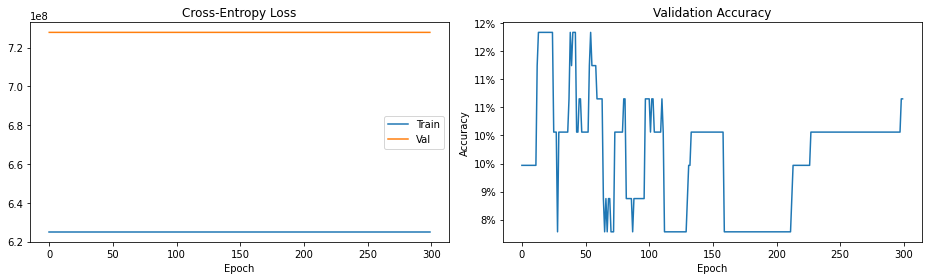


Best val accuracy : 11.8%
Majority-class baseline: 33.7%


In [16]:
EPOCHS     = 300
BATCH_SIZE = 32
LR         = 1e-3

# Precompute valid-action masks for every training and validation sample.
# During training the masked logits prevent the model from ever assigning
# probability to impossible actions, which speeds up convergence.
masks_train = compute_masks(X_train)
masks_val   = compute_masks(X_val)

train_dl = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train),
        torch.from_numpy(masks_train),
    ),
    batch_size=BATCH_SIZE, shuffle=True,
)

optimizer  = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
criterion  = nn.CrossEntropyLoss()
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=40, factor=0.5, verbose=False)

history = {"train_loss": [], "val_loss": [], "val_acc": []}

_NEG_INF = -1e9   # applied to invalid-action logits before softmax

for epoch in range(1, EPOCHS + 1):
    # â”€â”€ Train â”€â”€
    model.train()
    epoch_loss = 0.0
    for xb, yb, mb in train_dl:
        optimizer.zero_grad()
        logits        = model(xb)
        logits_masked = logits + (mb - 1) * _NEG_INF   # zero mask â†’ -inf
        loss          = criterion(logits_masked, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    history["train_loss"].append(epoch_loss / len(X_train))

    # â”€â”€ Validate â”€â”€
    model.eval()
    with torch.no_grad():
        val_logits        = model(torch.from_numpy(X_val))
        val_logits_masked = val_logits + (torch.from_numpy(masks_val) - 1) * _NEG_INF
        val_loss          = criterion(val_logits_masked, torch.from_numpy(y_val)).item()
        val_acc           = (val_logits_masked.argmax(1).numpy() == y_val).mean()
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    scheduler.step(val_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"train_loss={history['train_loss'][-1]:.4f}  "
              f"val_loss={val_loss:.4f}  "
              f"val_acc={val_acc:.1%}")

# â”€â”€ Training curves â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_acc"])
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0%}"))

plt.tight_layout()
plt.show()

print(f"\nBest val accuracy : {max(history['val_acc']):.1%}")
print(f"Majority-class baseline: {np.bincount(y_val).max() / len(y_val):.1%}")

### Confusion Matrix (Action Types)

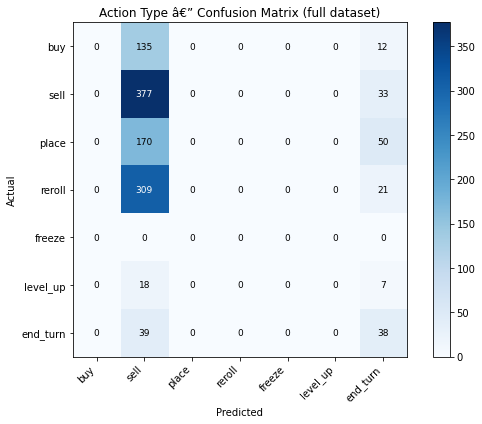

Per-type accuracy:
  buy       : 0/147 = 0.0%
  sell      : 377/410 = 92.0%
  place     : 0/220 = 0.0%
  reroll    : 0/330 = 0.0%
  level_up  : 0/25 = 0.0%
  end_turn  : 38/77 = 49.4%


In [17]:
from sklearn.metrics import confusion_matrix

model.eval()
with torch.no_grad():
    all_preds = model(torch.from_numpy(X_all)).argmax(1).numpy()

def action_type(a: int) -> str:
    if a < 7:   return "buy"
    if a < 14:  return "sell"
    if a == 14: return "place"
    if a == 15: return "reroll"
    if a == 16: return "freeze"
    if a == 17: return "level_up"
    return "end_turn"

type_labels   = ["buy", "sell", "place", "reroll", "freeze", "level_up", "end_turn"]
actual_types  = [action_type(a) for a in y_all]
pred_types    = [action_type(a) for a in all_preds]

cm = confusion_matrix(actual_types, pred_types, labels=type_labels)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(type_labels)))
ax.set_yticks(range(len(type_labels)))
ax.set_xticklabels(type_labels, rotation=45, ha="right")
ax.set_yticklabels(type_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Action Type â€” Confusion Matrix (full dataset)")
plt.colorbar(im, ax=ax)
thresh = cm.max() / 2
for i in range(len(type_labels)):
    for j in range(len(type_labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=9)
plt.tight_layout()
plt.show()

print("Per-type accuracy:")
for lbl in type_labels:
    mask    = np.array([a == lbl for a in actual_types])
    correct = sum(p == lbl for p, m in zip(pred_types, mask) if m)
    total   = mask.sum()
    if total:
        print(f"  {lbl:10s}: {correct}/{total} = {correct/total:.1%}")

### Step-by-step Prediction on a Sample Turn

Pick a game and round, then walk through the shopping phase showing the model's top-3 action predictions vs what was actually done.

In [18]:
SAMPLE_GAME  = 0   # change to inspect different games
SAMPLE_ROUND = -1  # -1 = last round

g        = games[SAMPLE_GAME]
r        = g["rounds"][SAMPLE_ROUND]
shopping = r["shopping"]

round_num = r["round"]
tier      = shopping.get("tavern_tier", 1)
health    = shopping.get("hero_health", 30)
armor     = shopping.get("hero_armor",  0)
shop      = list(shopping.get("shop_at_start",  []))
board     = list(shopping.get("board_at_start", []))
hand      = []
gold      = shopping.get("gold_at_start", 0)

hero_name = card_name(g["hero"]["card_id"]) if g.get("hero") else "?"
print(f"Hero: {hero_name}   Round {round_num}   Tier {tier}   HP {health}+{armor}   Gold {gold}")
print(f"Shop : {[card_name(m['card_id']) for m in shop]}")
print(f"Board: {[card_name(m['card_id']) for m in board]}")
print()

model.eval()
actions = shopping.get("actions", [])

for step, action in enumerate(actions + [{"action": "end_turn"}]):
    atype = action.get("action", "end_turn")
    cid   = action.get("card_id", "")

    gold = action.get("gold_remaining", gold)
    actual_str = atype + (f" {card_name(cid)}" if cid else "")

    state_vec = encode_state(round_num, tier, health, armor, shop, board, hand, gold)
    mask      = torch.tensor(valid_action_mask(state_vec), dtype=torch.float32)

    with torch.no_grad():
        logits        = model(torch.tensor(state_vec, dtype=torch.float32).unsqueeze(0)).squeeze(0)
        logits_masked = logits + (mask - 1) * 1e9
        probs         = torch.softmax(logits_masked, dim=0)
        top3          = probs.topk(3)

    n_valid  = int(mask.sum().item())
    top3_str = "  ".join(
        f"{ACTION_NAMES[i.item()]} ({p.item():.0%})"
        for i, p in zip(top3.indices, top3.values)
    )
    _match = [idx for idx,n in enumerate(ACTION_NAMES) if n.startswith(atype[:4])]
    if not _match:
        gold = max(0, gold)
        continue  # skip unknown action types (e.g. play_spell)
    match = "✓" if action_type(top3.indices[0].item()) == action_type(
        _match[0] if atype != "end_turn" else 18
    ) else " "
    print(f"Step {step+1:2d} {match}  gold={gold:2d}  valid={n_valid:2d}  "
          f"actual={actual_str:<30s}  predicted={top3_str}")

    # Update state
    if atype == "buy":
        idx = find_by_card_id(shop, cid)
        if idx >= 0: hand.append(shop.pop(idx))
        gold -= 3
    elif atype == "sell":
        idx = find_by_card_id(board, cid)
        if idx >= 0: board.pop(idx)
        gold += 1
    elif atype == "place":
        idx = find_by_card_id(hand, cid)
        if idx >= 0: board.append(hand.pop(idx))
    elif atype == "reroll":
        shop = []
        gold -= 1
    elif atype == "level_up":
        tier = min(tier + 1, 6)
    gold = max(0, gold)

Hero: The Rat King   Round 14   Tier 6   HP 30+0   Gold 10
Shop : ['Leeroy the Reckless', 'Deadly Spore', 'Air Revenant', 'Brann Bronzebeard']
Board: ['Air Revenant', 'Deadly Spore', 'Acid Rainfall', 'Acid Rainfall', 'Air Revenant', 'Brann Bronzebeard', 'Leeroy the Reckless']

Step  1 ✓  gold=10  valid=14  actual=sell Deadly Spore               predicted=sell_0 (100%)  buy_0 (0%)  buy_1 (0%)
Step  2 ✓  gold=11  valid=13  actual=sell                            predicted=sell_0 (100%)  buy_0 (0%)  buy_1 (0%)
Step  3    gold=12  valid=13  actual=place Archaedas                 predicted=sell_0 (100%)  buy_0 (0%)  buy_1 (0%)
Step  4 ✓  gold=12  valid=13  actual=sell Archaedas                  predicted=sell_0 (100%)  buy_0 (0%)  buy_1 (0%)
Step  5 ✓  gold=13  valid=13  actual=sell                            predicted=sell_0 (100%)  buy_0 (0%)  buy_1 (0%)
Step  6 ✓  gold=10  valid=13  actual=sell                            predicted=sell_0 (100%)  buy_0 (0%)  buy_1 (0%)
Step  7 ✓  gold=11  

### Save / Load Model

In [19]:
MODEL_PATH = Path("bg_policy.pt")

torch.save({
    "state_dict": model.state_dict(),
    "state_dim":  STATE_DIM,
    "n_actions":  N_ACTIONS,
    "action_names": ACTION_NAMES,
    "n_games_trained": len(games),
}, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

# To reload later:
# checkpoint = torch.load(MODEL_PATH)
# model = BGPolicy(checkpoint['state_dim'], checkpoint['n_actions'])
# model.load_state_dict(checkpoint['state_dict'])

Model saved to bg_policy.pt


---
## Neurosymbolic Layer

The symbolic layer computes deterministic mechanical quantities: multiplier detection, tribal density, aura dependency scores, and effect duration profiles. These features feed directly into the Transformer policy network.

In [20]:
# Load card definitions and build symbolic components
import sys
sys.path.insert(0, ".")

from symbolic.board_computer import SymbolicBoardComputer, BoardFeatures
from symbolic.shop_analyzer  import ShopAnalyzer
from agent.card_encoder      import CardEncoder, CARD_FEATURE_DIM, TRIBE_LIST, TRIGGER_TYPES, DURATION_TYPES
import numpy as np

with open("bg_card_definitions.json") as _f:
    _defs_raw = json.load(_f)
CARD_DEFS = _defs_raw['cards']

board_computer = SymbolicBoardComputer(CARD_DEFS)
shop_analyzer  = ShopAnalyzer(CARD_DEFS, board_computer)
card_encoder   = CardEncoder(CARD_DEFS)

# Reverse lookup: lower-cased name → card_def
_NAME_TO_DEF = {v['name'].lower(): v for v in CARD_DEFS.values()}

def enrich_minion(m):
    """Attach card_def key using the hearthstone library name lookup."""
    raw_name = card_name(m.get('card_id', '')) if m.get('card_id') else m.get('name', '')
    cdef = _NAME_TO_DEF.get(raw_name.lower())
    if cdef:
        sym_id = next((k for k, v in CARD_DEFS.items() if v['name'] == cdef['name']), m.get('card_id', ''))
        return dict(m, card_id=sym_id, _has_def=True)
    return dict(m, _has_def=False)

print(f"Card definitions loaded : {len(CARD_DEFS)}")
print(f"Card feature dimension  : {CARD_FEATURE_DIM}")
print("Symbolic components ready.")

Card definitions loaded : 264
Card feature dimension  : 44
Symbolic components ready.


### Symbolic Board Analysis

For each game we analyse the **final board** through the symbolic layer: multipliers, dominant tribe, aura dependency, and effect duration profile.

In [21]:
def analyse_board(board, round_num, tier, gold=0):
    enriched = [enrich_minion(m) for m in board]
    return board_computer.compute(enriched, gold=gold, round_num=round_num, tavern_tier=tier)

rows_sym = []
for g in games:
    last_round = g['rounds'][-1]
    shopping   = last_round['shopping']
    combat     = last_round.get('combat') or {}
    board      = combat.get('player_board') or shopping.get('board_at_end', [])
    tier       = shopping.get('tavern_tier', 6)
    round_num  = last_round['round']
    gold       = shopping.get('gold_at_start', 10)
    hero       = card_name(g['hero']['card_id']) if g.get('hero') else '?'
    if not board:
        continue
    f = analyse_board(board, round_num, tier, gold)
    rows_sym.append({
        'hero': hero, 'round': round_num, 'tier': tier,
        'board_size': f.board_size, 'total_atk': f.total_atk, 'total_hp': f.total_hp,
        'brann': f.brann_active, 'titus': f.titus_active, 'drakkari': f.drakkari_active,
        'dominant_tribe': f.dominant_tribe or 'None',
        'is_synergistic': f.is_synergistic,
        'aura_dep': round(f.total_aura_dependency, 3),
        'perm_fx': f.permanent_effect_count, 'game_fx': f.this_game_count,
        'combat_fx': f.this_combat_count, 'dr_count': f.dr_count,
        'divine_shields': f.divine_shield_count, 'venomous': f.venomous_count,
        'reborn': f.reborn_count,
    })

df_sym = pd.DataFrame(rows_sym)
display(df_sym[['hero','round','tier','board_size','total_atk','total_hp',
                'dominant_tribe','is_synergistic','brann','titus','drakkari','aura_dep']])

,hero,round,tier,board_size,total_atk,total_hp,dominant_tribe,is_synergistic,brann,titus,drakkari,aura_dep
0,The Rat King,14,6,7,4471,4448,ELEMENTAL,True,True,False,False,0.0
1,Ambassador Faelin,14,6,8,1054,1227,MECH,True,False,False,False,0.0
2,Fungalmancer Flurgl,18,6,7,701,842,MURLOC,True,False,False,False,0.0
3,Varden Dawngrasp,17,6,7,6011,5777,ELEMENTAL,True,True,False,False,0.0
4,Arch-Villain Rafaam,14,6,7,124,221,BEAST,True,True,True,False,0.0


### Effect Duration Profile

The symbolic layer tags every board effect as `PERMANENT`, `THIS_GAME`, or `THIS_COMBAT`. Permanent buffs are worth ~3× a combat-only buff of equivalent stats.

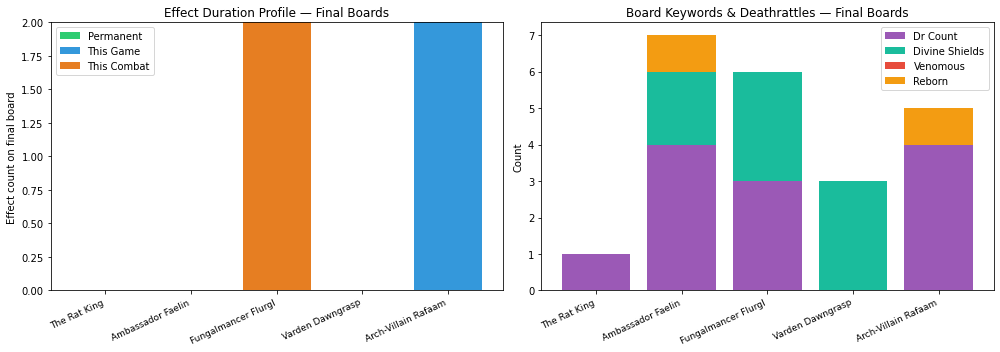

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

heroes = df_sym['hero'].tolist()
perm   = df_sym['perm_fx'].tolist()
game   = df_sym['game_fx'].tolist()
cbt    = df_sym['combat_fx'].tolist()
x = range(len(heroes))

axes[0].bar(x, perm, label='Permanent',   color='#2ecc71')
axes[0].bar(x, game, bottom=perm, label='This Game', color='#3498db')
axes[0].bar(x, cbt,  bottom=[p+g for p,g in zip(perm,game)], label='This Combat', color='#e67e22')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(heroes, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Effect count on final board')
axes[0].set_title('Effect Duration Profile — Final Boards')
axes[0].legend()

kw_labels = ['dr_count','divine_shields','venomous','reborn']
kw_colors = ['#9b59b6','#1abc9c','#e74c3c','#f39c12']
bottom = np.zeros(len(df_sym))
for label, color in zip(kw_labels, kw_colors):
    vals = df_sym[label].values.astype(float)
    axes[1].bar(x, vals, bottom=bottom, label=label.replace('_',' ').title(), color=color)
    bottom += vals
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(heroes, rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('Count')
axes[1].set_title('Board Keywords & Deathrattles — Final Boards')
axes[1].legend()
plt.tight_layout()
plt.show()

### Tribal Density Heatmap

A board is "synergistic" when ≥4 minions share a tribe. The heatmap shows per-tribe count for each game's final board.

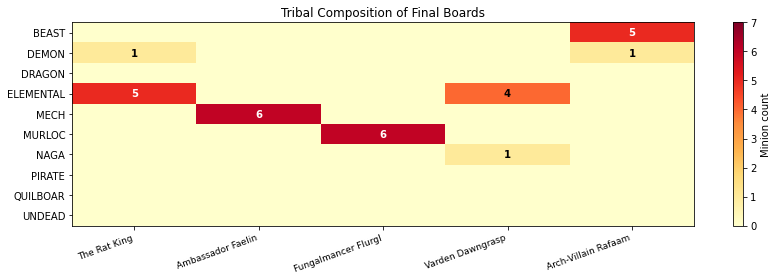

In [23]:
TRIBE_ORDER = ['BEAST','DEMON','DRAGON','ELEMENTAL','MECH',
               'MURLOC','NAGA','PIRATE','QUILBOAR','UNDEAD']

tribe_matrix = []
for g in games:
    last_round = g['rounds'][-1]
    shopping   = last_round['shopping']
    combat     = last_round.get('combat') or {}
    board      = combat.get('player_board') or shopping.get('board_at_end', [])
    tier       = shopping.get('tavern_tier', 6)
    round_num  = last_round['round']
    if not board:
        tribe_matrix.append([0]*len(TRIBE_ORDER))
        continue
    feats = analyse_board(board, round_num, tier)
    tribe_matrix.append([feats.tribe_counts.get(t, 0) for t in TRIBE_ORDER])

tribe_arr = np.array(tribe_matrix)
heroes_all = [card_name(g['hero']['card_id']) for g in games]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(tribe_arr.T, cmap='YlOrRd', aspect='auto', vmin=0, vmax=7)
ax.set_yticks(range(len(TRIBE_ORDER)))
ax.set_yticklabels(TRIBE_ORDER)
ax.set_xticks(range(len(heroes_all)))
ax.set_xticklabels(heroes_all, rotation=20, ha='right', fontsize=9)
ax.set_title('Tribal Composition of Final Boards')
plt.colorbar(im, ax=ax, label='Minion count')
for i in range(len(TRIBE_ORDER)):
    for j in range(len(heroes_all)):
        v = tribe_arr[j, i]
        if v > 0:
            ax.text(j, i, int(v), ha='center', va='center',
                    color='white' if v >= 5 else 'black', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### Shop Analyzer — Buy Value Estimation

Score each shop card using `base_power + synergy_bonus + tempo_value + scaling_value`.

In [24]:
DEMO_GAME  = 2
DEMO_ROUND = 8

g2       = games[DEMO_GAME]
r2       = g2['rounds'][DEMO_ROUND]
s2       = r2['shopping']
board2   = [enrich_minion(m) for m in s2.get('board_at_start', [])]
shop2    = [enrich_minion(m) for m in s2.get('shop_at_start',  [])]
tier2    = s2.get('tavern_tier', 3)
gold2    = s2.get('gold_at_start', 7)

print(f"Hero: {card_name(g2['hero']['card_id'])}  Round {r2['round']}  Tier {tier2}  Gold {gold2}")
print('\nCurrent board:')
for m in board2:
    print(f"  {card_name(m.get('card_id','')) or '?':<30s}  {m['attack']}/{m['health']}")

feats2 = board_computer.compute(board2, gold=gold2, round_num=r2['round'], tavern_tier=tier2)
scores = shop_analyzer.analyze_shop(shop2, feats2, gold=gold2, tavern_tier=tier2)

print('\nShop card valuations:')
print(f"  {'Card':<30s} {'Base':>6} {'Synrg':>6} {'Tempo':>6} {'Scale':>6} {'Total':>6}  Rec")
for sv in scores:
    print(f"  {sv.name:<30s} {sv.base_power:6.3f} {sv.synergy_bonus:6.3f} "
          f"{sv.tempo_value:6.3f} {sv.scaling_value:6.3f} {sv.total_value:6.3f}  {sv.recommendation}")

Hero: Fungalmancer Flurgl  Round 9  Tier 5  Gold 10

Current board:
  Malchezaar, Prince of Dance     14/9
  bassgill                        7/3
  soul_rewinder                   8/6
  gormling_gourmet                19/9
  Timecap'n Hooktail              8/4
  intrepid_botanist               15/9
  Timewarped Sellemental          15/8

Shop card valuations:
  Card                             Base  Synrg  Tempo  Scale  Total  Rec
  Gormling Gourmet                1.314  0.000  0.200  0.050  0.563  strong_buy
  Intrepid Botanist               1.080  0.000  0.080  0.200  0.474  consider
                                  1.035  0.000  0.050  0.050  0.429  consider
                                  0.575  0.000  0.050  0.050  0.245  pass
                                  0.450  0.000  0.050  0.050  0.195  pass
  Soul Rewinder                   0.350  0.000  0.080  0.050  0.160  pass
                                  0.300  0.000  0.050  0.050  0.135  pass
  Bassgill                        

---
## Card Encoder — 44-Dim Feature Vector

Each minion is encoded as a **44-dimensional float32 vector**. Dims 0-11 are backward-compatible with the existing BC 11-dim encoding. Dims 12-43 add tribal identity, trigger types, effect durations, and board context.

In [25]:
DIM_LABELS = (
    ['attack/20', 'health/20']
    + ['taunt','divine_shield','reborn','venomous','windfury','golden','magnetic']
    + ['tier/7', 'zone_pos/7', 'is_present']
    + [f'tribe_{t}' for t in TRIBE_LIST]
    + [f'trig_{t}' for t in TRIGGER_TYPES] + ['trig_other']
    + [f'dur_{t}' for t in DURATION_TYPES]
    + ['is_multiplier','is_aura','scales_with_board']
    + ['perm_atk/20','perm_hp/20','avenge_n/5','dr_summons']
    + ['board_size/7','synergy','aura_dep','round/25','tier_ctx/7']
)
assert len(DIM_LABELS) == 44

# Encode a sample board
DEMO_GAME_ENC  = 0
DEMO_ROUND_ENC = 10

g3 = games[DEMO_GAME_ENC]
r3 = g3['rounds'][DEMO_ROUND_ENC]
s3 = r3['shopping']
board3   = [enrich_minion(m) for m in s3.get('board_at_end', [])]
tier3    = s3.get('tavern_tier', 4)
round3   = r3['round']

feats3   = board_computer.compute(board3, round_num=round3, tavern_tier=tier3)
dom_cnt  = max(feats3.tribe_counts.values(), default=0)

enc_board = card_encoder.encode_board(
    board3,
    board_size=feats3.board_size,
    dominant_tribe_count=dom_cnt,
    total_aura_dependency=feats3.total_aura_dependency,
    round_num=round3, tavern_tier=tier3,
)
print(f"Encoded board shape : {enc_board.shape}  (7 slots × 44 features)")
print(f"Active slots        : {feats3.board_size}")
print()

for i, row in enumerate(enc_board[:feats3.board_size]):
    m = board3[i]
    name = card_name(m.get('card_id', '')) or '?'
    nz   = [(DIM_LABELS[j], round(float(row[j]),3)) for j in range(44) if abs(row[j]) > 1e-4]
    print(f'Slot {i}: {name}')
    for label, val in nz:
        print(f'  [{label:22s}] = {val:.3f}')
    print()

Encoded board shape : (7, 44)  (7 slots × 44 features)
Active slots        : 7

Slot 0: acid_rainfall
  [attack/20             ] = 14.900
  [health/20             ] = 15.000
  [tier/7                ] = 0.857
  [zone_pos/7            ] = 0.143
  [is_present            ] = 1.000
  [tribe_ELEMENTAL       ] = 1.000
  [trig_other            ] = 1.000
  [board_size/7          ] = 1.000
  [synergy               ] = 0.571
  [round/25              ] = 0.440
  [tier_ctx/7            ] = 0.857

Slot 1: air_revenant
  [attack/20             ] = 1.900
  [health/20             ] = 1.400
  [golden                ] = 1.000
  [tier/7                ] = 0.714
  [zone_pos/7            ] = 0.286
  [is_present            ] = 1.000
  [tribe_ELEMENTAL       ] = 1.000
  [trig_other            ] = 1.000
  [board_size/7          ] = 1.000
  [synergy               ] = 0.571
  [round/25              ] = 0.440
  [tier_ctx/7            ] = 0.857

Slot 2: avalanche_caller
  [attack/20             ] = 0.300
  [healt

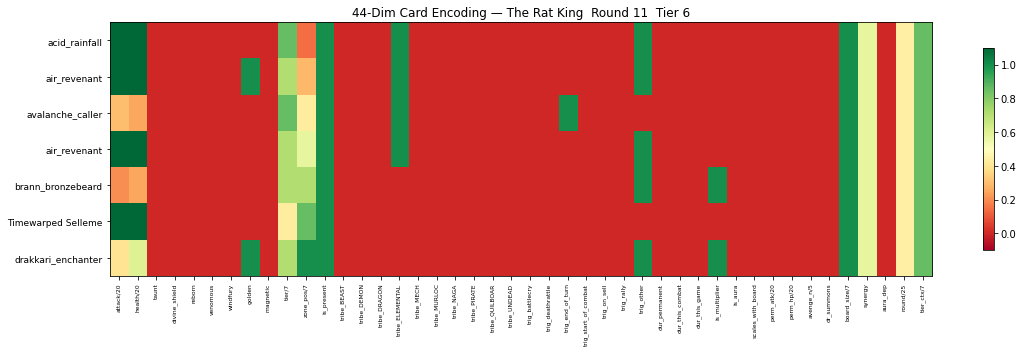

In [26]:
# Feature heatmap across board slots
fig, ax = plt.subplots(figsize=(16, 5))
slot_labels = [
    (card_name(m.get('card_id','')) or '?')[:18]
    for m in board3[:7]
] + ['(pad)'] * (7 - len(board3[:7]))
im = ax.imshow(enc_board, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=1.1)
ax.set_xticks(range(44))
ax.set_xticklabels(DIM_LABELS, rotation=90, fontsize=6)
ax.set_yticks(range(7))
ax.set_yticklabels(slot_labels, fontsize=9)
hero3 = card_name(g3['hero']['card_id'])
ax.set_title(f'44-Dim Card Encoding — {hero3}  Round {round3}  Tier {tier3}')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---
## PPO Policy Network

The `BGPolicyNetwork` is a Transformer encoder over 17 tokens ([CLS + 7 board + 7 shop + 2 hand]), fused with a 24-dim scalar context. Separate policy and value heads produce action logits and a state value estimate.

In [27]:
import torch
from agent.policy import BGPolicyNetwork, build_action_mask
from agent.policy import N_ACTIONS as N_PPO, ACTION_NAMES as PPO_ACTIONS

policy = BGPolicyNetwork(card_dim=44, d_model=128, nhead=4, num_layers=3, n_actions=N_PPO)
n_params = sum(p.numel() for p in policy.parameters())
print(f"PPO Policy parameters : {n_params:,}")
print(f"Action space          : {N_PPO} actions")
print(f"Actions               : {PPO_ACTIONS}")
print()
print(policy)

PPO Policy parameters : 672,789
Action space          : 20 actions
Actions               : ['buy_0', 'buy_1', 'buy_2', 'buy_3', 'buy_4', 'buy_5', 'buy_6', 'sell_0', 'sell_1', 'sell_2', 'sell_3', 'sell_4', 'sell_5', 'sell_6', 'play', 'level_up', 'freeze', 'refresh', 'hero_power', 'end_turn']

BGPolicyNetwork(
  (card_proj): Linear(in_features=44, out_features=128, bias=True)
  (zone_embed): Embedding(3, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    

In [28]:
# Forward pass demo with a real shopping state
g4 = games[0]
r4 = g4['rounds'][5]
s4 = r4['shopping']

board4 = [enrich_minion(m) for m in s4.get('board_at_end', [])]
shop4  = [enrich_minion(m) for m in s4.get('shop_at_start', [])]
hand4  = []
tier4  = s4.get('tavern_tier', 2)
round4 = r4['round']
gold4  = s4.get('gold_at_start', 5)

def enc_zone(minions, tier, rnd):
    f = board_computer.compute(minions, round_num=rnd, tavern_tier=tier)
    dom = max(f.tribe_counts.values(), default=0)
    return card_encoder.encode_board(
        minions, board_size=f.board_size, dominant_tribe_count=dom,
        total_aura_dependency=f.total_aura_dependency, round_num=rnd, tavern_tier=tier
    ), f

board_enc4, bfeats4 = enc_zone(board4, tier4, round4)
shop_enc4,  _       = enc_zone(shop4,  tier4, round4)
hand_enc4,  _       = enc_zone(hand4,  tier4, round4)

board_t = torch.tensor(board_enc4,    dtype=torch.float32).unsqueeze(0)
shop_t  = torch.tensor(shop_enc4,     dtype=torch.float32).unsqueeze(0)
hand_t  = torch.tensor(hand_enc4[:2], dtype=torch.float32).unsqueeze(0)
scalar_t = torch.tensor(bfeats4.to_scalar_vector(), dtype=torch.float32).unsqueeze(0)

ps = {'gold': gold4, 'shop': shop4, 'board': board4, 'hand': hand4,
      'tavern_tier': tier4, 'level_cost': 5}
mask = build_action_mask(ps)

print(f"Board: {len(board4)} minions | Shop: {len(shop4)} cards | Gold: {gold4} | Tier: {tier4}")
print(f"Valid actions ({mask.sum().item()}): {[PPO_ACTIONS[i] for i,v in enumerate(mask) if v]}")
print()

policy.eval()
with torch.no_grad():
    logits, value = policy(board_t, shop_t, hand_t, scalar_t, mask.unsqueeze(0))
    probs = torch.softmax(logits, dim=-1).squeeze(0)
    top5  = probs.topk(min(5, int(mask.sum().item())))

print(f"State value estimate : {value.item():.4f}")
print("\nTop action predictions (untrained — random init):")
for idx, prob in zip(top5.indices, top5.values):
    name = PPO_ACTIONS[idx.item()]
    bar  = chr(9608) * int(prob.item() * 40)
    print(f"  {name:<14s} {prob.item():.3f}  {bar}")

Board: 5 minions | Shop: 6 cards | Gold: 8 | Tier: 5
Valid actions (16): ['buy_0', 'buy_1', 'buy_2', 'buy_3', 'buy_4', 'buy_5', 'sell_0', 'sell_1', 'sell_2', 'sell_3', 'sell_4', 'level_up', 'freeze', 'refresh', 'hero_power', 'end_turn']

State value estimate : 0.2914

Top action predictions (untrained — random init):
  end_turn       0.153  ██████
  buy_3          0.100  ███
  freeze         0.093  ███
  sell_1         0.090  ███
  buy_2          0.087  ███


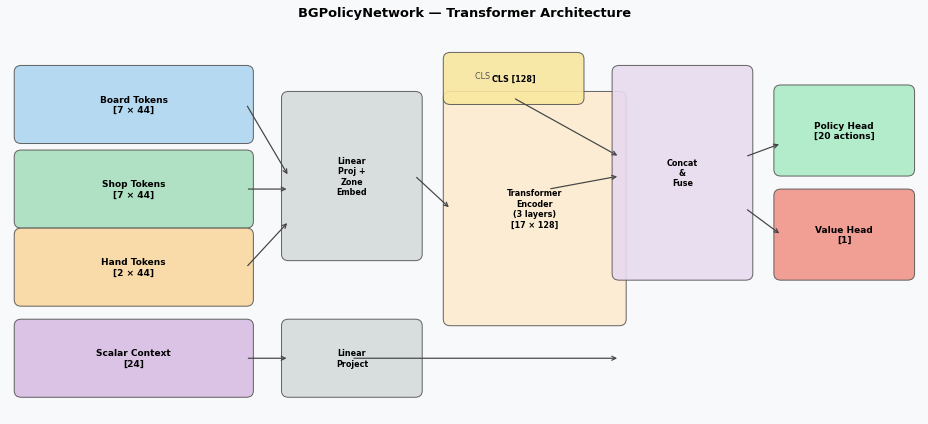

In [29]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13); ax.set_ylim(0, 6); ax.axis('off')
ax.set_facecolor('#f8f9fa'); fig.patch.set_facecolor('#f8f9fa')

def box(x, y, w, h, text, color, fs=9):
    r = FancyBboxPatch((x,y), w, h, boxstyle='round,pad=0.1',
                       lw=1, edgecolor='#555', facecolor=color, alpha=0.9)
    ax.add_patch(r)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fs, fontweight='bold')

def arrow(x1,y1,x2,y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

box(0.2, 4.3, 3.2, 1.0, 'Board Tokens\n[7 × 44]',     '#AED6F1')
box(0.2, 3.0, 3.2, 1.0, 'Shop Tokens\n[7 × 44]',      '#A9DFBF')
box(0.2, 1.8, 3.2, 1.0, 'Hand Tokens\n[2 × 44]',      '#FAD7A0')
box(0.2, 0.4, 3.2, 1.0, 'Scalar Context\n[24]',        '#D7BDE2')
box(4.0, 2.5, 1.8, 2.4, 'Linear\nProj +\nZone\nEmbed', '#D5DBDB', 8)
arrow(3.4, 4.8, 4.0, 3.7); arrow(3.4, 3.5, 4.0, 3.5); arrow(3.4, 2.3, 4.0, 3.0)
box(6.3, 1.5, 2.4, 3.4, 'Transformer\nEncoder\n(3 layers)\n[17 × 128]', '#FDEBD0', 8)
arrow(5.8, 3.7, 6.3, 3.2)
ax.text(6.65, 5.2, 'CLS →', fontsize=8, color='#555')
box(6.3, 4.9, 1.8, 0.6, 'CLS [128]', '#F9E79F', 8)
box(4.0, 0.4, 1.8, 1.0, 'Linear\nProject', '#D5DBDB', 8)
arrow(3.4, 0.9, 4.0, 0.9); arrow(4.9, 0.9, 8.7, 0.9)
box(8.7, 2.2, 1.8, 3.1, 'Concat\n&\nFuse', '#E8DAEF', 8)
arrow(7.7, 3.5, 8.7, 3.7); arrow(7.2, 4.9, 8.7, 4.0)
box(11.0, 3.8, 1.8, 1.2, 'Policy Head\n[20 actions]', '#ABEBC6')
box(11.0, 2.2, 1.8, 1.2, 'Value Head\n[1]',           '#F1948A')
arrow(10.5, 4.0, 11.0, 4.2); arrow(10.5, 3.2, 11.0, 2.8)
ax.set_title('BGPolicyNetwork — Transformer Architecture', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout(); plt.show()

### 24-Dim Scalar Context Vector

Beyond the card tokens, the policy receives a 24-dim scalar summary: combat win-probability, multiplier flags, tribal densities, and board metrics.

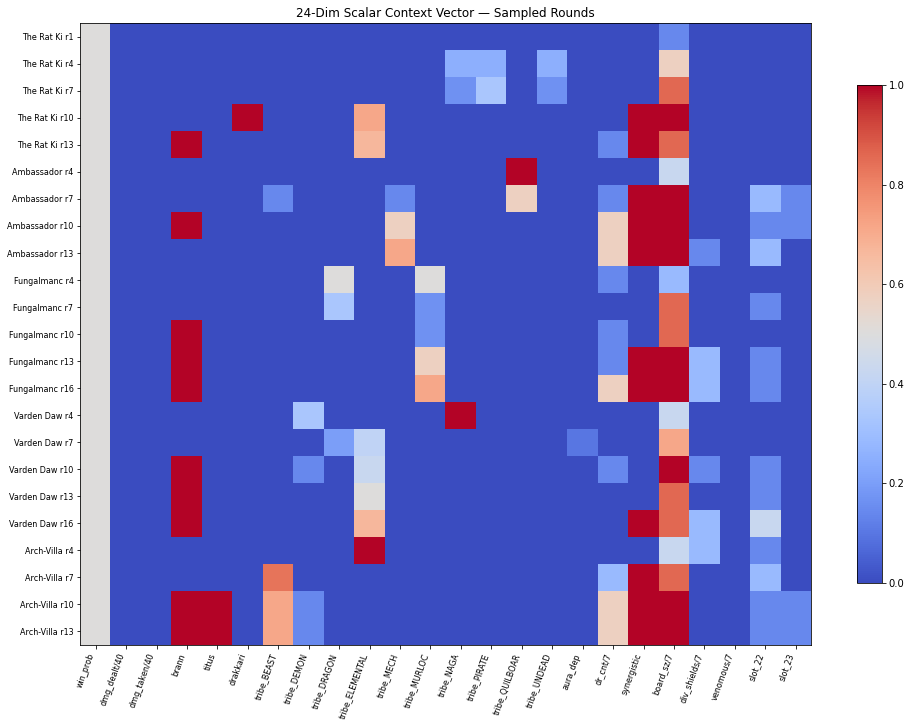

In [30]:
SCALAR_LABELS = [
    'win_prob','dmg_dealt/40','dmg_taken/40',
    'brann','titus','drakkari',
    'tribe_BEAST','tribe_DEMON','tribe_DRAGON','tribe_ELEMENTAL',
    'tribe_MECH','tribe_MURLOC','tribe_NAGA','tribe_PIRATE',
    'tribe_QUILBOAR','tribe_UNDEAD',
    'aura_dep','dr_cnt/7','synergistic',
    'board_sz/7','div_shields/7','venomous/7',
    'slot_22','slot_23',
]

all_scalars, all_meta = [], []
for g in games:
    hero = card_name(g['hero']['card_id'])
    for r in g['rounds'][::3]:
        s = r['shopping']
        board = [enrich_minion(m) for m in s.get('board_at_end', [])]
        if not board: continue
        f = board_computer.compute(board, round_num=r['round'], tavern_tier=s.get('tavern_tier',1))
        all_scalars.append(f.to_scalar_vector())
        all_meta.append(f"{hero[:10]} r{r['round']}")

scalar_matrix = np.stack(all_scalars)
fig, ax = plt.subplots(figsize=(14, max(4, len(all_scalars)*0.4 + 1)))
im = ax.imshow(scalar_matrix, cmap='coolwarm', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(24))
ax.set_xticklabels(SCALAR_LABELS, rotation=70, ha='right', fontsize=8)
ax.set_yticks(range(len(all_meta)))
ax.set_yticklabels(all_meta, fontsize=8)
ax.set_title('24-Dim Scalar Context Vector — Sampled Rounds')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()